In [1]:
# IMPORT STATEMENTS
import sys
sys.path.append("/booleanfs2/sahoo/Hegemon/")
sys.path = ["/booleanfs2/sahoo/BoNE/"] + sys.path

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

try:
    reload  # Python 2.7
except NameError:
    try:
        from importlib import reload  # Python 3.4+
    except ImportError:
        from imp import reload  # Python 3.0 - 3.3
        
import SMaRT.MacUtils as mut
reload(mut)
import bone
reload(bone)
# import Datasets
# reload(Datasets)
pd = bone.pd
np = bone.np
re = bone.re
hu = bone.hu

Figure 2C

Models in file: ['ElasticNet', 'Huber', 'LinearSVR', 'OLS', 'Ridge']  (n_models = 5 )


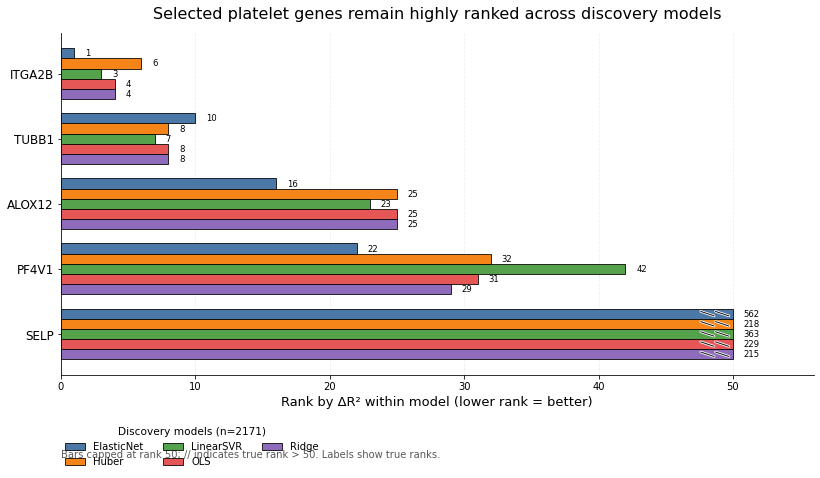

In [17]:
fp = "ML_deltaR2_rankings_6models.tsv"
df = pd.read_csv(fp, sep="\t")
disc = ['TUBB1','ITGA2B','ALOX12','PF4V1', 'SELP']

models = df["model"].unique()
print("Models in file:", list(models), " (n_models =", len(models), ")")

rows = []
for m in models:
    d = df[df["model"] == m].copy().sort_values("delta_R2", ascending=False).reset_index(drop=True)
    d["rank"] = np.arange(1, len(d) + 1)
    for g in disc:
        hit = d[d["gene"] == g]
        if hit.empty:
            rows.append({"model": m, "gene": g, "rank": np.nan})
        else:
            rows.append({"model": m, "gene": g, "rank": int(hit.iloc[0]["rank"])})

rank_disc = pd.DataFrame(rows)

pivot = rank_disc.pivot(index="gene", columns="model", values="rank").reindex(disc)
# print(pivot)

disc = ['ITGA2B', 'TUBB1', 'ALOX12', 'PF4V1', 'SELP']
pivot = pivot.reindex(disc)

models = list(pivot.columns)
n_models = len(models)

n_total = None
try:
    n_total = int(df["n"].iloc[0])
except:
    pass

RANK_CAP = 50

fig, ax = plt.subplots(figsize=(11.5, 6.8))

y = np.arange(len(disc))
bar_h = 0.78 / n_models

colors = ['#4C78A8', '#F58518', '#54A24B', '#E45756', '#8E6CBB'][:n_models]

for i, (m, color) in enumerate(zip(models, colors)):
    raw_ranks = pivot[m].values.astype(float)
    draw_ranks = np.minimum(raw_ranks, RANK_CAP)
    ypos = y - 0.39 + bar_h/2 + i * bar_h

    bars = ax.barh(
        ypos,
        draw_ranks,
        height=bar_h,
        color=color,
        edgecolor="black",
        linewidth=0.8,
        label=m,
        zorder=3
    )

    for bar, raw_r, draw_r, yy in zip(bars, raw_ranks, draw_ranks, ypos):
        if not np.isfinite(raw_r):
            continue

        label_x = min(draw_r + 0.8, RANK_CAP + 2.6)
        ax.text(
            label_x, yy, f"{int(raw_r)}",
            va="center", ha="left",
            fontsize=8.5,
            color="black", zorder=7
        )

        if raw_r > RANK_CAP:
            x_right = RANK_CAP - 0.5
            dy = bar_h * 0.22

            # white underlay
            ax.plot([x_right - 0.8, x_right + 0.2], [yy - dy, yy + dy],
                    color="white", lw=2.6, zorder=8, solid_capstyle="round")
            ax.plot([x_right - 1.9, x_right - 0.9], [yy - dy, yy + dy],
                    color="white", lw=2.6, zorder=8, solid_capstyle="round")

            # black slashes
            ax.plot([x_right - 0.8, x_right + 0.2], [yy - dy, yy + dy],
                    color="black", lw=0.9, zorder=9, solid_capstyle="round")
            ax.plot([x_right - 1.9, x_right - 0.9], [yy - dy, yy + dy],
                    color="black", lw=0.9, zorder=9, solid_capstyle="round")

# axes
ax.set_yticks(y)
ax.set_yticklabels(disc, fontsize=12)
ax.set_xlabel("Rank by ΔR² within model (lower rank = better)", fontsize=13)
ax.set_title("Selected platelet genes remain highly ranked across discovery models", fontsize=16, pad=14)

# normal left-to-right axis
ax.set_xlim(0, RANK_CAP + 6)
ax.invert_yaxis()

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", linestyle="--", alpha=0.22, zorder=0)

# legend at bottom-left
legend_title = "Discovery models"
if n_total is not None:
    legend_title += f" (n={n_total})"

ax.legend(
    title=legend_title,
    frameon=False,
    fontsize=10,
    title_fontsize=10.5,
    ncol=min(3, n_models),
    loc="upper left",
    bbox_to_anchor=(0.0, -0.14),
    borderaxespad=0
)

# note
ax.text(
    0.0, -0.24,
    f"Bars capped at rank {RANK_CAP}; // indicates true rank > {RANK_CAP}. Labels show true ranks.",
    transform=ax.transAxes,
    fontsize=10,
    color="0.35"
)

plt.tight_layout()

# plt.savefig("fig-2-b-1-selected_genes_rank_barplot_horizontal.pdf", dpi=400, bbox_inches="tight")

plt.show()


Figure 2D

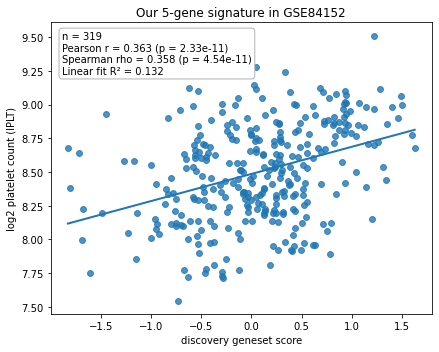

Genes found: ['SELP', 'TUBB1', 'ITGA2B', 'ALOX12', 'PF4V1']
n = 319
Pearson r = 0.3628, p = 2.328e-11
Spearman rho = 0.3578, p = 4.541e-11
Linear fit R^2 = 0.1316, slope p = 2.328e-11


In [3]:
import os
import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, linregress

# INPUT

OUR_SIG_NAME = "discovery geneset"
OUR_SIG_GENES = ['SELP', 'TUBB1', 'ITGA2B', 'ALOX12', 'PF4V1']
files = ["merged_gene_plt_tables/COV314__c_platelet__merged.tsv", ]

# HELPERS

def normalize_name(x: str) -> str:
    return re.sub(r'[^A-Za-z0-9]+', '', str(x).strip().upper())

def infer_platelet_col(df: pd.DataFrame):
    preferred = [
        "PLT",
        "platelet",
        "platelets",
        "platelet_count",
        "blood.platelet.count",
        "pplts",
        "c_platelet",
        "c_platelets",
        "c_platelet_count",
        "c_blood.platelet.count",
        "c_pplts",
    ]

    exact_map = {str(c).strip(): c for c in df.columns}
    norm_map = {normalize_name(c): c for c in df.columns}

    for name in preferred:
        if name in exact_map:
            return exact_map[name]
        n = normalize_name(name)
        if n in norm_map:
            return norm_map[n]
    return None

def ensure_lplt(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    if "lPLT" in df.columns:
        df["lPLT"] = pd.to_numeric(df["lPLT"], errors="coerce")
        return df.replace([np.inf, -np.inf], np.nan)

    raw_col = infer_platelet_col(df)
    if raw_col is None:
        raise ValueError("Could not find a platelet column.")

    raw = pd.to_numeric(df[raw_col], errors="coerce")
    raw[raw <= 0] = np.nan
    df["lPLT"] = np.log2(raw)

    return df.replace([np.inf, -np.inf], np.nan)

def build_gene_to_col_map(df: pd.DataFrame):
    gene_to_col = {}

    for col in df.columns:
        c = str(col).strip()
        if c.upper().startswith("EXP_"):
            gene = c[4:].strip().upper()
            if gene:
                gene_to_col[gene] = c

    for col in df.columns:
        c = str(col).strip()
        cu = c.upper()
        if cu in {"DATASET", "LPLT", "PLT"}:
            continue
        if cu not in gene_to_col:
            gene_to_col[cu] = c

    return gene_to_col

def zscore_df(X: pd.DataFrame) -> pd.DataFrame:
    X = X.apply(pd.to_numeric, errors="coerce")
    mu = X.mean(axis=0)
    sd = X.std(axis=0, ddof=0).replace(0, np.nan)
    return (X - mu) / sd

def compute_signature_score(df: pd.DataFrame, sig_genes, gene_to_col,
                            min_frac_genes_present=0.70,
                            min_genes_abs=2,
                            min_frac_genes_per_sample=0.50):
    sig_genes = [g.upper() for g in sig_genes]

    cols = []
    genes_found = []
    for g in sig_genes:
        c = gene_to_col.get(g)
        if c is not None:
            cols.append(c)
            genes_found.append(g)

    min_needed = max(min_genes_abs, math.ceil(min_frac_genes_present * len(sig_genes)))
    if len(cols) < min_needed:
        return None, genes_found

    X = df[cols].copy().apply(pd.to_numeric, errors="coerce")

    keep_cols = [c for c in X.columns if X[c].nunique(dropna=True) > 1]
    X = X[keep_cols]

    if X.shape[1] < min_needed:
        return None, genes_found

    Xz = zscore_df(X)

    min_non_missing = max(1, math.ceil(min_frac_genes_per_sample * X.shape[1]))
    nn = Xz.notna().sum(axis=1)
    score = Xz.mean(axis=1, skipna=True)
    score[nn < min_non_missing] = np.nan

    return score, genes_found

# LOAD DATA + COMPUTE SIGNATURE SCORE

fp = files[0]
df = pd.read_csv(fp, sep="\t")
df = ensure_lplt(df)

gene_to_col = build_gene_to_col_map(df)
score, genes_found = compute_signature_score(df, OUR_SIG_GENES, gene_to_col)

if score is None:
    raise ValueError(f"Insufficient gene coverage. Found genes: {genes_found}")

plot_df = pd.DataFrame({
    "score": score,
    "lPLT": df["lPLT"]
}).dropna()

if len(plot_df) < 3:
    raise ValueError("Too few samples after dropping missing values.")

# STATS

x = plot_df["score"].values
y = plot_df["lPLT"].values
n = len(plot_df)

pear_r, pear_p = pearsonr(x, y)
spear_rho, spear_p = spearmanr(x, y)

fit = linregress(x, y)
slope = fit.slope
intercept = fit.intercept
r_value = fit.rvalue
r2 = r_value**2
line_p = fit.pvalue


# PLOT
fig, ax = plt.subplots(figsize=(6.2, 5.0))
ax.scatter(x, y, alpha=0.8, s=35)
# regression line
xx = np.linspace(np.min(x), np.max(x), 200)
yy = intercept + slope * xx
ax.plot(xx, yy, linewidth=2)

ax.set_xlabel(f"{OUR_SIG_NAME} score")
ax.set_ylabel("log2 platelet count (lPLT)")
ax.set_title("Our 5-gene signature in GSE84152")
txt = (
    f"n = {n}\n"
    f"Pearson r = {pear_r:.3f} (p = {pear_p:.2e})\n"
    f"Spearman rho = {spear_rho:.3f} (p = {spear_p:.2e})\n"
    f"Linear fit R² = {r2:.3f}"
)
ax.text(
    0.03, 0.97, txt,
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="0.7")
)

plt.tight_layout()
# plt.savefig("COV314_Our5gene_regression_plot.pdf", dpi=400, bbox_inches="tight")
# plt.savefig("COV314_Our5gene_regression_plot.png", dpi=400, bbox_inches="tight")
plt.show()

print("Genes found:", genes_found)
print(f"n = {n}")
print(f"Pearson r = {pear_r:.4f}, p = {pear_p:.3e}")
print(f"Spearman rho = {spear_rho:.4f}, p = {spear_p:.3e}")
print(f"Linear fit R^2 = {r2:.4f}, slope p = {line_p:.3e}")

Figure 2E

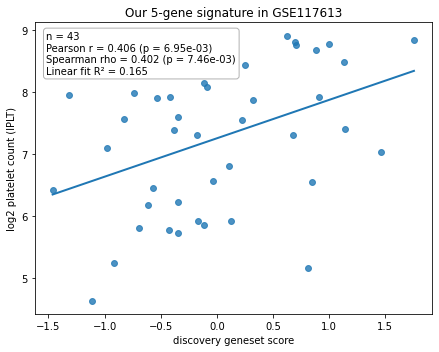

Genes found: ['SELP', 'TUBB1', 'ITGA2B', 'ALOX12', 'PF4V1']
n = 43
Pearson r = 0.4057, p = 6.951e-03
Spearman rho = 0.4025, p = 7.456e-03
Linear fit R^2 = 0.1646, slope p = 6.951e-03


In [6]:
import os
import re
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, linregress

# INPUT

OUR_SIG_NAME = "discovery geneset"
OUR_SIG_GENES = ['SELP', 'TUBB1', 'ITGA2B', 'ALOX12', 'PF4V1']

files = ["merged_gene_plt_tables/MACV306__c_platelet__merged.tsv",]

# HELPERS

def normalize_name(x: str) -> str:
    return re.sub(r'[^A-Za-z0-9]+', '', str(x).strip().upper())

def infer_platelet_col(df: pd.DataFrame):
    preferred = [
        "PLT",
        "platelet",
        "platelets",
        "platelet_count",
        "blood.platelet.count",
        "pplts",
        "c_platelet",
        "c_platelets",
        "c_platelet_count",
        "c_blood.platelet.count",
        "c_pplts",
    ]

    exact_map = {str(c).strip(): c for c in df.columns}
    norm_map = {normalize_name(c): c for c in df.columns}

    for name in preferred:
        if name in exact_map:
            return exact_map[name]
        n = normalize_name(name)
        if n in norm_map:
            return norm_map[n]
    return None

def ensure_lplt(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    if "lPLT" in df.columns:
        df["lPLT"] = pd.to_numeric(df["lPLT"], errors="coerce")
        return df.replace([np.inf, -np.inf], np.nan)

    raw_col = infer_platelet_col(df)
    if raw_col is None:
        raise ValueError("Could not find a platelet column.")

    raw = pd.to_numeric(df[raw_col], errors="coerce")
    raw[raw <= 0] = np.nan
    df["lPLT"] = np.log2(raw)

    return df.replace([np.inf, -np.inf], np.nan)

def build_gene_to_col_map(df: pd.DataFrame):
    gene_to_col = {}

    for col in df.columns:
        c = str(col).strip()
        if c.upper().startswith("EXP_"):
            gene = c[4:].strip().upper()
            if gene:
                gene_to_col[gene] = c

    for col in df.columns:
        c = str(col).strip()
        cu = c.upper()
        if cu in {"DATASET", "LPLT", "PLT"}:
            continue
        if cu not in gene_to_col:
            gene_to_col[cu] = c

    return gene_to_col

def zscore_df(X: pd.DataFrame) -> pd.DataFrame:
    X = X.apply(pd.to_numeric, errors="coerce")
    mu = X.mean(axis=0)
    sd = X.std(axis=0, ddof=0).replace(0, np.nan)
    return (X - mu) / sd

def compute_signature_score(df: pd.DataFrame, sig_genes, gene_to_col,
                            min_frac_genes_present=0.70,
                            min_genes_abs=2,
                            min_frac_genes_per_sample=0.50):
    sig_genes = [g.upper() for g in sig_genes]

    cols = []
    genes_found = []
    for g in sig_genes:
        c = gene_to_col.get(g)
        if c is not None:
            cols.append(c)
            genes_found.append(g)

    min_needed = max(min_genes_abs, math.ceil(min_frac_genes_present * len(sig_genes)))
    if len(cols) < min_needed:
        return None, genes_found

    X = df[cols].copy().apply(pd.to_numeric, errors="coerce")

    keep_cols = [c for c in X.columns if X[c].nunique(dropna=True) > 1]
    X = X[keep_cols]

    if X.shape[1] < min_needed:
        return None, genes_found

    Xz = zscore_df(X)

    min_non_missing = max(1, math.ceil(min_frac_genes_per_sample * X.shape[1]))
    nn = Xz.notna().sum(axis=1)
    score = Xz.mean(axis=1, skipna=True)
    score[nn < min_non_missing] = np.nan

    return score, genes_found

# LOAD DATA + COMPUTE SIGNATURE SCORE

fp = files[0]
df = pd.read_csv(fp, sep="\t")
df = ensure_lplt(df)

gene_to_col = build_gene_to_col_map(df)
score, genes_found = compute_signature_score(df, OUR_SIG_GENES, gene_to_col)

if score is None:
    raise ValueError(f"Insufficient gene coverage. Found genes: {genes_found}")

plot_df = pd.DataFrame({
    "score": score,
    "lPLT": df["lPLT"]
}).dropna()

if len(plot_df) < 3:
    raise ValueError("Too few samples after dropping missing values.")

# STATS

x = plot_df["score"].values
y = plot_df["lPLT"].values
n = len(plot_df)

pear_r, pear_p = pearsonr(x, y)
spear_rho, spear_p = spearmanr(x, y)

fit = linregress(x, y)
slope = fit.slope
intercept = fit.intercept
r_value = fit.rvalue
r2 = r_value**2
line_p = fit.pvalue


# PLOT
fig, ax = plt.subplots(figsize=(6.2, 5.0))
ax.scatter(x, y, alpha=0.8, s=35)
# regression line
xx = np.linspace(np.min(x), np.max(x), 200)
yy = intercept + slope * xx
ax.plot(xx, yy, linewidth=2)

ax.set_xlabel(f"{OUR_SIG_NAME} score")
ax.set_ylabel("log2 platelet count (lPLT)")
ax.set_title("Our 5-gene signature in GSE117613")
txt = (
    f"n = {n}\n"
    f"Pearson r = {pear_r:.3f} (p = {pear_p:.2e})\n"
    f"Spearman rho = {spear_rho:.3f} (p = {spear_p:.2e})\n"
    f"Linear fit R² = {r2:.3f}"
)
ax.text(
    0.03, 0.97, txt,
    transform=ax.transAxes,
    ha="left", va="top",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="0.7")
)

plt.tight_layout()
# plt.savefig("COV314_Our5gene_regression_plot.pdf", dpi=400, bbox_inches="tight")
# plt.savefig("COV314_Our5gene_regression_plot.png", dpi=400, bbox_inches="tight")
plt.show()

print("Genes found:", genes_found)
print(f"n = {n}")
print(f"Pearson r = {pear_r:.4f}, p = {pear_p:.3e}")
print(f"Spearman rho = {spear_rho:.4f}, p = {spear_p:.3e}")
print(f"Linear fit R^2 = {r2:.4f}, slope p = {line_p:.3e}")

Figure 2G

In [14]:
import os
outdir = "signature_benchmark_outputs_spearman_only"
os.makedirs(outdir, exist_ok=True)
results_path = os.path.join(outdir, "per_dataset_spearman.tsv")
ranks_path = os.path.join(outdir, "per_dataset_spearman_with_ranks.tsv")
summary_path = os.path.join(outdir, "summary_spearman.tsv")

results_df = pd.read_csv(results_path, sep="\t")
rank_df = pd.read_csv(ranks_path, sep="\t")
summary_df = pd.read_csv(summary_path, sep="\t")

from scipy.stats import wilcoxon
pairwise_rows = []
pivot_rho = rank_df.pivot(index="dataset", columns="signature", values="spearman_rho")

signature_files = {
    "S3-PMID_27403440": "ranking_outputs_strategy_B/PMID_27403440_newline.txt",
    "S7-PMID_1322202": "ranking_outputs_strategy_B/PMID_1322202_newline.txt",
    "S8-HP_0011873": "ranking_outputs_strategy_B/HP_0011873_newline.txt",
    "S11-HP_0008320": "ranking_outputs_strategy_B/HP_0008320_newline.txt",
    "S10-PMID_11413156-HPIA": "ranking_outputs_strategy_B/PMID_11413156-HPIA.txt",
    "S9-HP_0001902-HPGP": "ranking_outputs_strategy_B/HP_0001902-HPGP.txt",
    "S4-GO_0036344-GOBP": "ranking_outputs_strategy_B/GO_0036344-GOBP.txt",
    "S12-PMID_17353439": "ranking_outputs_strategy_B/PMID_17353439-RAGHAVACHARI.txt",
    "S5-PMID_8467233": "ranking_outputs_strategy_B/PMID_8467233-GOCC-AG.txt",
    "S6-PMID_11487378": "ranking_outputs_strategy_B/PMID_11487378-GOCC.txt",
    "S2-PMID_12433680": "ranking_outputs_strategy_B/PMID_12433680-GNATENKO.txt",
    "S1-PMID_37258682": "ranking_outputs_strategy_B/PMID_37258682-gavish.txt",
}

def load_signature_txt(path: str):
    genes = []
    seen = set()
    with open(path, "r") as f:
        for line in f:
            g = line.strip()
            if not g:
                continue
            g = g.upper()
            if g not in seen:
                genes.append(g)
                seen.add(g)
    return genes

signatures = {OUR_SIG_NAME: [g.upper() for g in OUR_SIG_GENES]}
for sig_name, path in signature_files.items():
    signatures[sig_name] = load_signature_txt(path)

for sig_name in signatures:
    if sig_name == OUR_SIG_NAME:
        continue

    if OUR_SIG_NAME not in pivot_rho.columns or sig_name not in pivot_rho.columns:
        pairwise_rows.append({
            "reference_signature": OUR_SIG_NAME,
            "other_signature": sig_name,
            "n_paired_datasets": 0,
            "median_diff_rho": np.nan,
            "wilcoxon_stat": np.nan,
            "wilcoxon_p": np.nan,
            "note": "missing_signature_column"
        })
        continue

    paired = pivot_rho[[OUR_SIG_NAME, sig_name]].dropna()
    n_paired = len(paired)

    if n_paired < 3:
        pairwise_rows.append({
            "reference_signature": OUR_SIG_NAME,
            "other_signature": sig_name,
            "n_paired_datasets": n_paired,
            "median_diff_rho": np.nan,
            "wilcoxon_stat": np.nan,
            "wilcoxon_p": np.nan,
            "note": "too_few_paired_datasets"
        })
        continue

    diffs = paired[OUR_SIG_NAME] - paired[sig_name]

    # two-sided is safer for reporting; change to alternative="greater" if desired
    try:
        stat, p = wilcoxon(paired[OUR_SIG_NAME], paired[sig_name], alternative="two-sided")
    except ValueError:
        stat, p = np.nan, np.nan

    pairwise_rows.append({
        "reference_signature": OUR_SIG_NAME,
        "other_signature": sig_name,
        "n_paired_datasets": n_paired,
        "median_diff_rho": float(np.median(diffs)),
        "wilcoxon_stat": float(stat) if pd.notna(stat) else np.nan,
        "wilcoxon_p": float(p) if pd.notna(p) else np.nan,
        "note": ""
    })

pairwise_df = pd.DataFrame(pairwise_rows).sort_values("median_diff_rho", ascending=False)


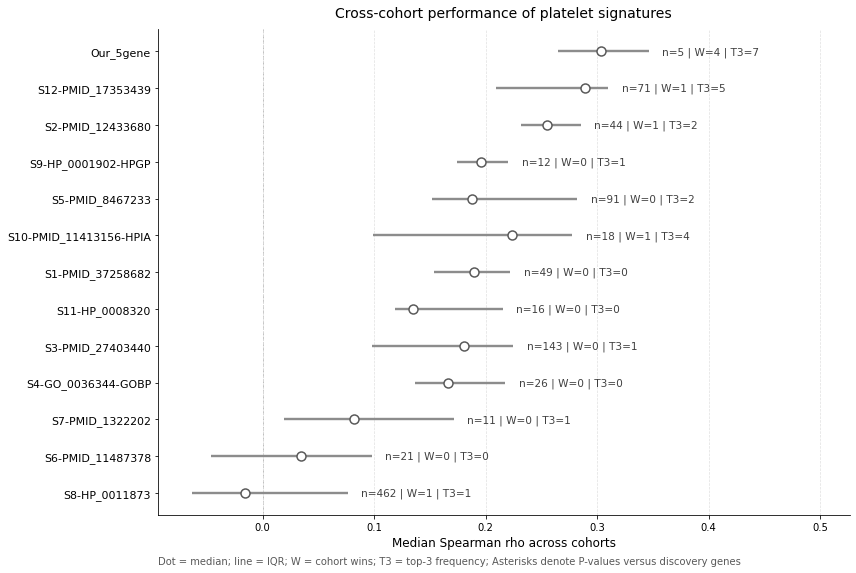

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sig_order = summary_df["signature"].tolist()

plot_rows = []
for sig in sig_order:
    vals = rank_df.loc[rank_df["signature"] == sig, "spearman_rho"].dropna().values

    if len(vals) == 0:
        q1 = med = q3 = np.nan
    else:
        q1 = np.percentile(vals, 25)
        med = np.median(vals)
        q3 = np.percentile(vals, 75)

    row_sum = summary_df.loc[summary_df["signature"] == sig].iloc[0]
    wins = int(row_sum["wins_spearman"])
    top3 = int(row_sum["top3_spearman"])

    # number of genes in the signature
    n_genes = int(rank_df.loc[rank_df["signature"] == sig, "n_genes_total"].dropna().iloc[0])

    # Wilcoxon significance stars vs Our_5gene
    ptxt = ""
    if sig != OUR_SIG_NAME:
        sub = pairwise_df[pairwise_df["other_signature"] == sig]
        if len(sub) > 0 and pd.notna(sub.iloc[0]["wilcoxon_p"]):
            p = sub.iloc[0]["wilcoxon_p"]
            if p < 0.001:
                ptxt = "***"
            elif p < 0.01:
                ptxt = "**"
            elif p < 0.05:
                ptxt = "*"

    plot_rows.append({
        "signature": sig,
        "q1": q1,
        "median": med,
        "q3": q3,
        "wins": wins,
        "top3": top3,
        "n_genes": n_genes,
        "star": ptxt
    })

plot_df = pd.DataFrame(plot_rows)
ypos = np.arange(len(plot_df))[::-1]

fig, ax = plt.subplots(figsize=(12, 8))

# Explicit colors so matplotlib does not cycle automatically
main_color = "black"
other_line_color = "0.55"  
other_dot_face = "white"
other_dot_edge = "0.35"

# draw rows
for i, row in plot_df.iterrows():
    y = ypos[i]
    sig = row["signature"]

    if sig == OUR_SIG_NAME:
        line_color = main_color
        dot_face = main_color
        dot_edge = main_color
        lw = 3.4
        ms = 11
        z = 5
        fontweight = "bold"
    else:
        line_color = other_line_color
        dot_face = other_dot_face
        dot_edge = other_dot_edge
        lw = 2.4
        ms = 9
        z = 3
        fontweight = "normal"

    # IQR line
    ax.hlines(
        y=y,
        xmin=row["q1"],
        xmax=row["q3"],
        color=line_color,
        linewidth=lw,
        zorder=z
    )

    # Median dot
    ax.scatter(
        row["median"], y,
        s=ms**2,
        facecolor=dot_face,
        edgecolor=dot_edge,
        linewidth=1.5,
        zorder=z + 1
    )

    # Right-side label
    label_x = row["q3"] + 0.012
    label_txt = f"n={row['n_genes']} | W={row['wins']} | T3={row['top3']}{row['star']}"
    ax.text(
        label_x, y, label_txt,
        va="center",
        fontsize=10.5,
        color="black" if sig == OUR_SIG_NAME else "0.25",
        fontweight=fontweight
    )

# y labels
ax.set_yticks(ypos)
ax.set_yticklabels(plot_df["signature"], fontsize=11)

# x label / title
ax.set_xlabel("Median Spearman rho across cohorts", fontsize=12)
ax.set_title("Cross-cohort performance of platelet signatures", fontsize=14, pad=12)

# x=0 reference line
ax.axvline(0, linestyle="--", linewidth=1, color="0.75", zorder=1)

# remove top/right spines for cleaner journal look
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# light x-grid only
ax.grid(axis="x", linestyle="--", linewidth=0.7, color="0.88")
ax.grid(axis="y", visible=False)

# add space on right for labels
xmin = np.nanmin(plot_df["q1"].values)
xmax = np.nanmax(plot_df["q3"].values)
ax.set_xlim(min(-0.05, xmin - 0.03), xmax + 0.18)

note = "Dot = median; line = IQR; W = cohort wins; T3 = top-3 frequency; Asterisks denote P-values versus discovery genes"
ax.text(
    0.0, -0.10, note,
    transform=ax.transAxes,
    fontsize=10,
    color="0.35"
)

plt.tight_layout()
plt.show()
